# Suspicion Score Analysis

Explore how the per-round suspicion statistic `sus(u, t)` and its cumulative average `Sus(t)` accumulate under different speaker types, without focusing on the switching mechanism itself.

In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from rsa import *
from rsa.experimental import SuspicionSwitchListener, simulate_suspicion_listener
from rsa.speaker0 import Speaker0
from rsa.listener0 import Listener0
from rsa.speaker1 import Speaker1

## Setup

Helper to run a single simulation and collect per-round `sus(u, t)` values.
We use `c=float('inf')` so the listener **never** switches — we just observe the
raw suspicion trajectory.

In [3]:
def run_suspicion_sim(theta, speaker_type, rounds=30, alpha=3.0,
                      n=1, m=7, seed=None):
    """
    Run one simulation and return per-round sus scores and Sus(t) trajectory.
    The listener never switches (c=inf).
    """
    if seed is not None:
        np.random.seed(seed)

    thetas = make_thetas(0.1, True, True)
    psis   = ['inf', 'high', 'low']
    world     = make_world(theta=theta, n=n, m=m)
    semantics = make_semantics(n=n)

    s0 = Speaker0(thetas, semantics=semantics, world=world)
    l0 = Listener0(thetas, s0, semantics=semantics, world=world)
    s1 = Speaker1(thetas, l0, semantics=semantics, world=world,
                  alpha=alpha, psi=speaker_type)

    # c=inf → listener never switches; we just observe statistics
    listener = SuspicionSwitchListener(
        thetas, psis, s1, world, semantics,
        c=float('inf'), alpha=alpha, hard_switch=True
    )

    per_round_sus = []
    sus_running   = []
    sigma_running = []
    utterances    = []

    for _ in range(rounds):
        obs = world.sample_obs()
        utt = s1.sample_utterance(obs)

        # Compute per-round sus BEFORE updating
        sus_t, var_t = listener._compute_sus_and_var(utt)
        per_round_sus.append(sus_t)

        listener.update(utt)
        s1.update(obs)
        l0.update(utt)
        s0.update(obs)

        sus_running.append(listener.Sus_running)
        sigma_running.append(np.sqrt(listener.sigma2_running))
        utterances.append(utt)

    return {
        'per_round_sus': np.array(per_round_sus),
        'Sus_running':   np.array(sus_running),
        'sigma_running': np.array(sigma_running),
        'utterances':    utterances,
    }


def run_many_sims(theta, speaker_type, n_sims=100, rounds=30,
                  alpha=3.0, n=1, m=7):
    """Run n_sims independent simulations, return arrays of shape (n_sims, rounds)."""
    all_per_round = []
    all_Sus       = []
    all_sigma     = []
    for i in range(n_sims):
        res = run_suspicion_sim(theta, speaker_type, rounds=rounds,
                                alpha=alpha, n=n, m=m)
        all_per_round.append(res['per_round_sus'])
        all_Sus.append(res['Sus_running'])
        all_sigma.append(res['sigma_running'])
    return {
        'per_round_sus': np.array(all_per_round),   # (n_sims, rounds)
        'Sus_running':   np.array(all_Sus),           # (n_sims, rounds)
        'sigma_running': np.array(all_sigma),         # (n_sims, rounds)
    }

print('Setup done.')

Setup done.


## 1. Single Simulation: Per-Round and Cumulative Sus

Compare one run of an informative speaker vs a persuasive speaker.

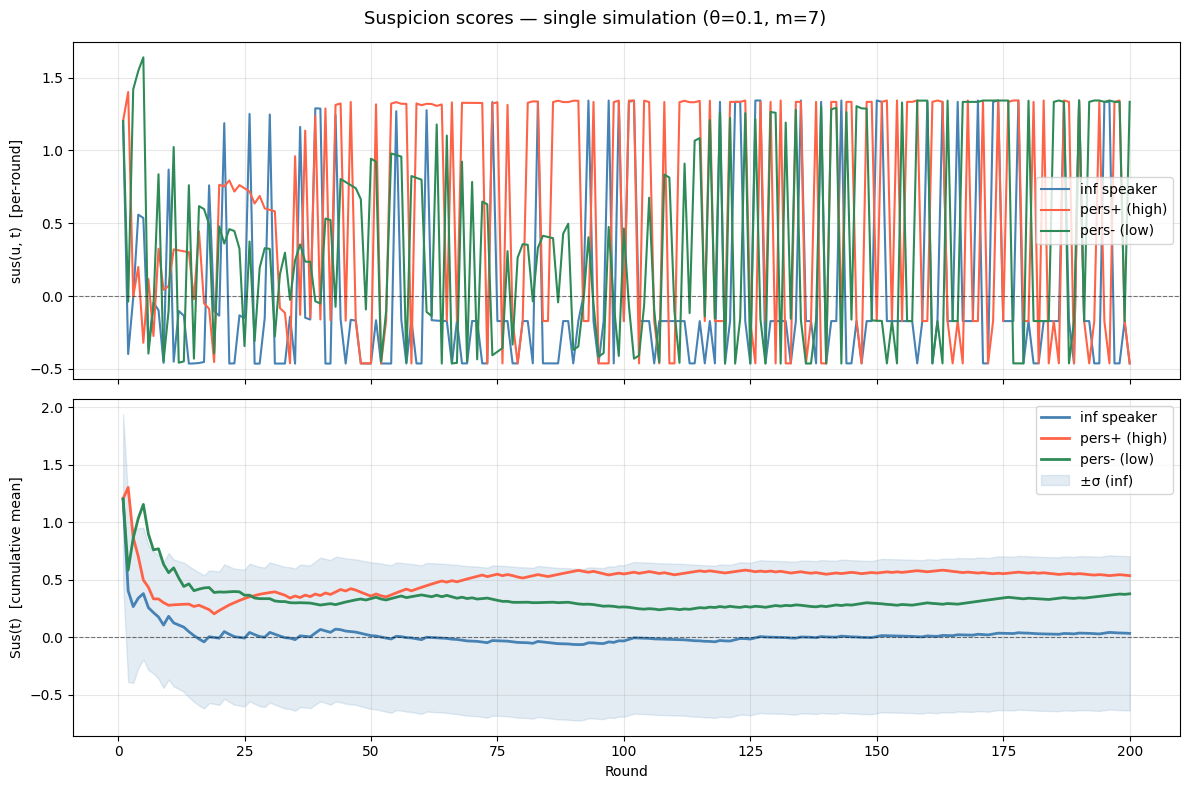

In [5]:
THETA  = 0.1
ROUNDS = 200
ALPHA  = 3.0
N, M   = 1, 7

res_inf  = run_suspicion_sim(THETA, 'inf',  rounds=ROUNDS, alpha=ALPHA, n=N, m=M, seed=0)
res_high = run_suspicion_sim(THETA, 'high', rounds=ROUNDS, alpha=ALPHA, n=N, m=M, seed=0)
res_low  = run_suspicion_sim(THETA, 'low',  rounds=ROUNDS, alpha=ALPHA, n=N, m=M, seed=0)

rounds_ax = np.arange(1, ROUNDS + 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f'Suspicion scores — single simulation (θ={THETA}, m={M})', fontsize=13)

# Per-round sus(u, t)
ax = axes[0]
ax.plot(rounds_ax, res_inf['per_round_sus'],  label='inf speaker',   color='steelblue',  lw=1.5)
ax.plot(rounds_ax, res_high['per_round_sus'], label='pers+ (high)',  color='tomato',     lw=1.5)
ax.plot(rounds_ax, res_low['per_round_sus'],  label='pers- (low)',   color='seagreen',   lw=1.5)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_ylabel('sus(u, t)  [per-round]')
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative Sus(t)
ax = axes[1]
ax.plot(rounds_ax, res_inf['Sus_running'],  label='inf speaker',  color='steelblue',  lw=2)
ax.plot(rounds_ax, res_high['Sus_running'], label='pers+ (high)', color='tomato',     lw=2)
ax.plot(rounds_ax, res_low['Sus_running'],  label='pers- (low)',  color='seagreen',   lw=2)
ax.fill_between(rounds_ax,
                res_inf['Sus_running'] - res_inf['sigma_running'],
                res_inf['Sus_running'] + res_inf['sigma_running'],
                color='steelblue', alpha=0.15, label='±σ (inf)')
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Round')
ax.set_ylabel('Sus(t)  [cumulative mean]')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Averaged Over Many Simulations

Average trajectories across `n_sims` independent runs to see the expected behaviour.

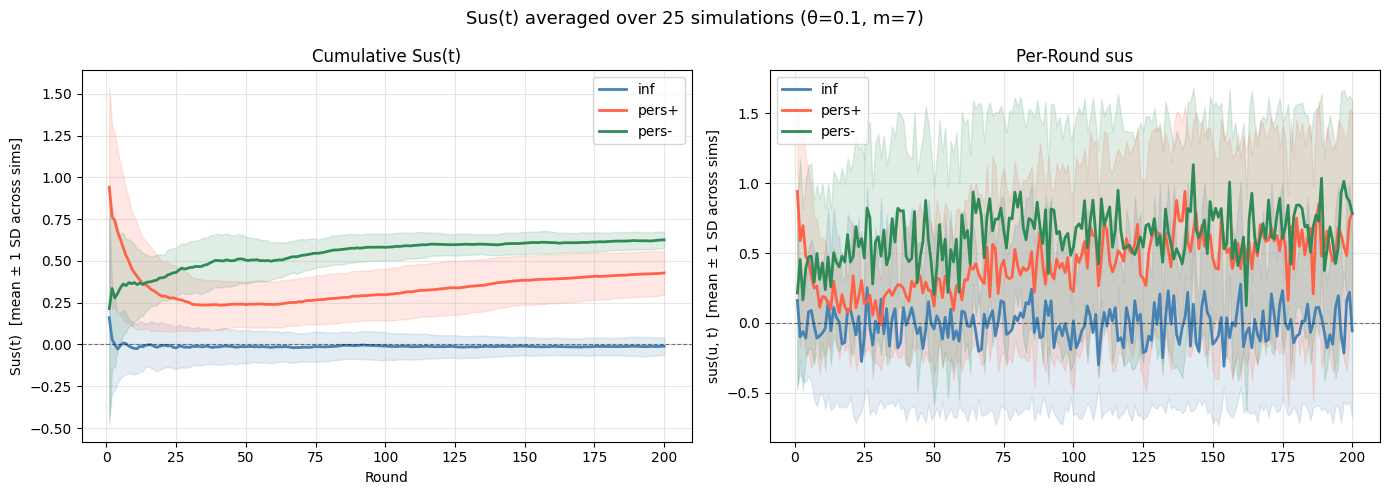

In [6]:
N_SIMS = 25

data_inf  = run_many_sims(THETA, 'inf',  n_sims=N_SIMS, rounds=ROUNDS, alpha=ALPHA, n=N, m=M)
data_high = run_many_sims(THETA, 'high', n_sims=N_SIMS, rounds=ROUNDS, alpha=ALPHA, n=N, m=M)
data_low  = run_many_sims(THETA, 'low',  n_sims=N_SIMS, rounds=ROUNDS, alpha=ALPHA, n=N, m=M)

def plot_mean_band(ax, data_dict, color, label):
    x   = np.arange(1, data_dict['Sus_running'].shape[1] + 1)
    mu  = data_dict['Sus_running'].mean(axis=0)
    sd  = data_dict['Sus_running'].std(axis=0)
    ax.plot(x, mu, color=color, lw=2, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Sus(t) averaged over {N_SIMS} simulations (θ={THETA}, m={M})', fontsize=13)

# Left: Sus(t) trajectories
ax = axes[0]
plot_mean_band(ax, data_inf,  'steelblue', 'inf')
plot_mean_band(ax, data_high, 'tomato',    'pers+')
plot_mean_band(ax, data_low,  'seagreen',  'pers-')
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Round')
ax.set_ylabel('Sus(t)  [mean ± 1 SD across sims]')
ax.set_title('Cumulative Sus(t)')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: per-round sus(u, t) averaged
ax = axes[1]
for data, color, label in [
    (data_inf,  'steelblue', 'inf'),
    (data_high, 'tomato',    'pers+'),
    (data_low,  'seagreen',  'pers-'),
]:
    x  = np.arange(1, data['per_round_sus'].shape[1] + 1)
    mu = data['per_round_sus'].mean(axis=0)
    sd = data['per_round_sus'].std(axis=0)
    ax.plot(x, mu, color=color, lw=2, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.15)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('Round')
ax.set_ylabel('sus(u, t)  [mean ± 1 SD across sims]')
ax.set_title('Per-Round sus')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Distribution of Sus(T) at a Fixed Horizon

Look at the distribution of `Sus(T)` at the end of `T` rounds, across simulations.

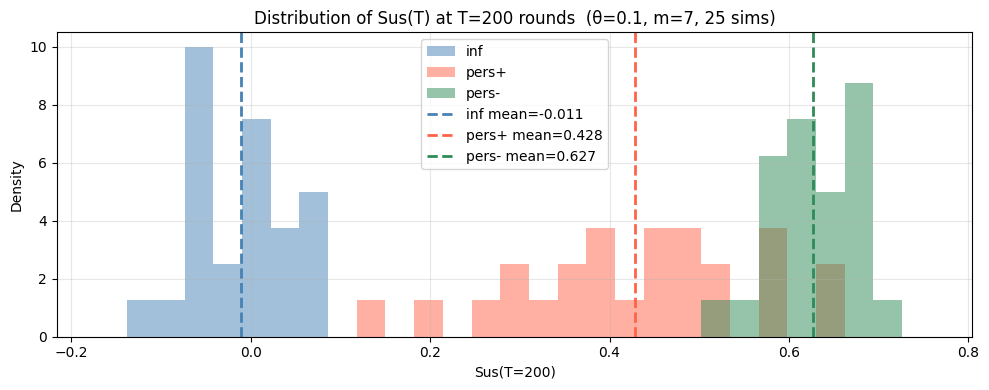

Sus(T) statistics at T=200:
  inf     : mean=-0.0109  std=0.0524  median=-0.0047  [p5=-0.0801, p95=0.0751]
  pers+   : mean=0.4283  std=0.1310  median=0.4487  [p5=0.2028, p95=0.6287]
  pers-   : mean=0.6265  std=0.0485  median=0.6300  [p5=0.5496, p95=0.6905]


In [7]:
final_inf  = data_inf['Sus_running'][:, -1]
final_high = data_high['Sus_running'][:, -1]
final_low  = data_low['Sus_running'][:, -1]

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(
    min(final_inf.min(), final_high.min(), final_low.min()) - 0.05,
    max(final_inf.max(), final_high.max(), final_low.max()) + 0.05,
    30
)
ax.hist(final_inf,  bins=bins, alpha=0.5, color='steelblue', label='inf',   density=True)
ax.hist(final_high, bins=bins, alpha=0.5, color='tomato',    label='pers+',  density=True)
ax.hist(final_low,  bins=bins, alpha=0.5, color='seagreen',  label='pers-',  density=True)

for vals, color, label in [
    (final_inf,  'steelblue', 'inf'),
    (final_high, 'tomato',    'pers+'),
    (final_low,  'seagreen',  'pers-'),
]:
    ax.axvline(vals.mean(), color=color, lw=2, ls='--',
               label=f'{label} mean={vals.mean():.3f}')

ax.set_xlabel(f'Sus(T={ROUNDS})')
ax.set_ylabel('Density')
ax.set_title(f'Distribution of Sus(T) at T={ROUNDS} rounds  (θ={THETA}, m={M}, {N_SIMS} sims)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Sus(T) statistics at T={ROUNDS}:")
for vals, lbl in [(final_inf, 'inf'), (final_high, 'pers+'), (final_low, 'pers-')]:
    print(f"  {lbl:8s}: mean={vals.mean():.4f}  std={vals.std():.4f}  "
          f"median={np.median(vals):.4f}  [p5={np.percentile(vals,5):.4f}, "
          f"p95={np.percentile(vals,95):.4f}]")

## 4. Effect of True θ

How does Sus(T) vary with the true theta, for each speaker type?

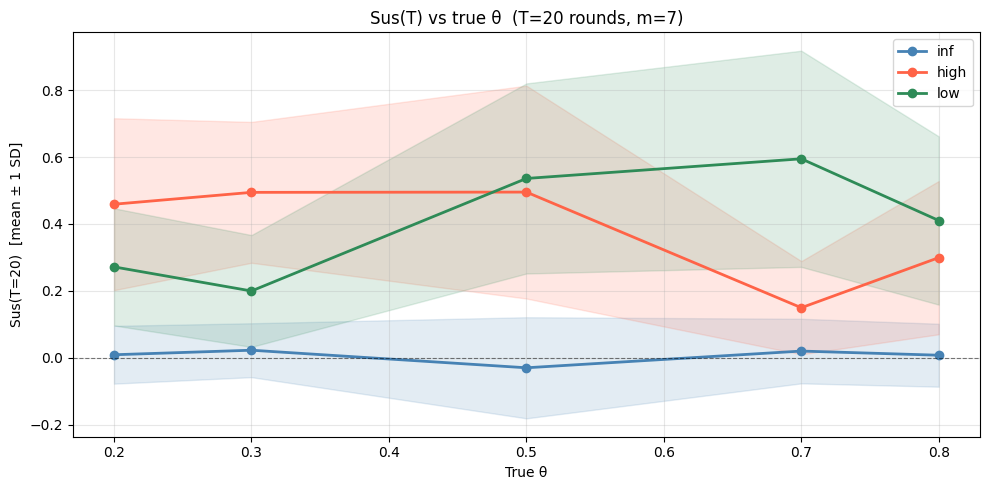

In [6]:
THETA_VALS = [0.2, 0.3, 0.5, 0.7, 0.8]
T_HORIZON  = 20
N_SIMS_S   = 40  # fewer sims for speed

mean_sus = {psi: [] for psi in ['inf', 'high', 'low']}
std_sus  = {psi: [] for psi in ['inf', 'high', 'low']}

for theta in THETA_VALS:
    for psi in ['inf', 'high', 'low']:
        d = run_many_sims(theta, psi, n_sims=N_SIMS_S, rounds=T_HORIZON,
                          alpha=ALPHA, n=N, m=M)
        finals = d['Sus_running'][:, -1]
        mean_sus[psi].append(finals.mean())
        std_sus[psi].append(finals.std())

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'inf': 'steelblue', 'high': 'tomato', 'low': 'seagreen'}
for psi in ['inf', 'high', 'low']:
    mu  = np.array(mean_sus[psi])
    sd  = np.array(std_sus[psi])
    ax.plot(THETA_VALS, mu, 'o-', color=colors[psi], lw=2, label=psi)
    ax.fill_between(THETA_VALS, mu - sd, mu + sd, color=colors[psi], alpha=0.15)

ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('True θ')
ax.set_ylabel(f'Sus(T={T_HORIZON})  [mean ± 1 SD]')
ax.set_title(f'Sus(T) vs true θ  (T={T_HORIZON} rounds, m={M})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Effect of α (Rationality) and m (Sessions)

How does the separation between null and alternative Sus(T) change with α and m?

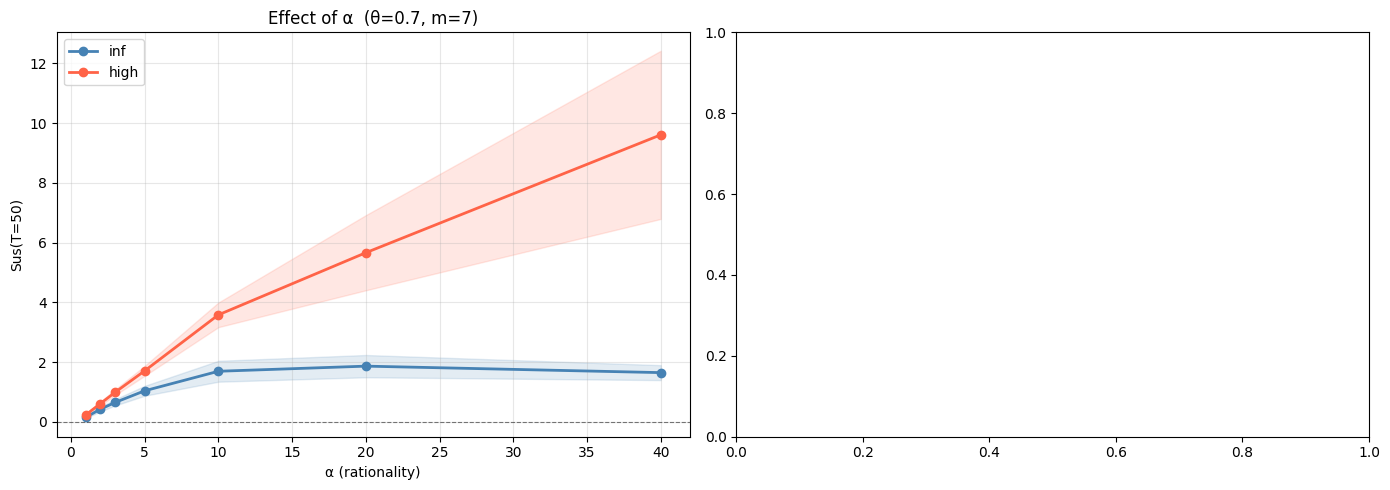

In [16]:
THETA_FIX = 0.7
ALPHA_VALS = [1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 40.0]
T_H = 50

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- α sweep ---
ax = axes[0]
for psi, color in [('inf', 'steelblue'), ('high', 'tomato')]:
    mus, sds = [], []
    for alpha in ALPHA_VALS:
        d = run_many_sims(THETA_FIX, psi, n_sims=N_SIMS_S, rounds=T_H,
                          alpha=alpha, n=N, m=M)
        finals = d['Sus_running'][:, -1]
        mus.append(finals.mean())
        sds.append(finals.std())
    mus, sds = np.array(mus), np.array(sds)
    ax.plot(ALPHA_VALS, mus, 'o-', color=color, lw=2, label=psi)
    ax.fill_between(ALPHA_VALS, mus - sds, mus + sds, color=color, alpha=0.15)

ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel('α (rationality)')
ax.set_ylabel(f'Sus(T={T_H})')
ax.set_title(f'Effect of α  (θ={THETA_FIX}, m={M})')
ax.legend()
ax.grid(True, alpha=0.3)

# --- m sweep ---
# M_VALS = [2, 3, 5, 7, 10]
# ax = axes[1]
# for psi, color in [('inf', 'steelblue'), ('high', 'tomato')]:
#     mus, sds = [], []
#     for m_val in M_VALS:
#         d = run_many_sims(THETA_FIX, psi, n_sims=N_SIMS_S, rounds=T_H,
#                           alpha=ALPHA, n=N, m=m_val)
#         finals = d['Sus_running'][:, -1]
#         mus.append(finals.mean())
#         sds.append(finals.std())
#     mus, sds = np.array(mus), np.array(sds)
#     ax.plot(M_VALS, mus, 'o-', color=color, lw=2, label=psi)
#     ax.fill_between(M_VALS, mus - sds, mus + sds, color=color, alpha=0.15)

# ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.5)
# ax.set_xlabel('m (sessions per patient)')
# ax.set_ylabel(f'Sus(T={T_H})')
# ax.set_title(f'Effect of m  (θ={THETA_FIX}, α={ALPHA})')
# ax.legend()
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Sus(t) / σ(t) Ratio Over Time

The switching criterion is `Sus(t) > c · σ(t)`. Plot the ratio `Sus(t) / σ(t)` to see
how many standard deviations above zero the cumulative score sits.

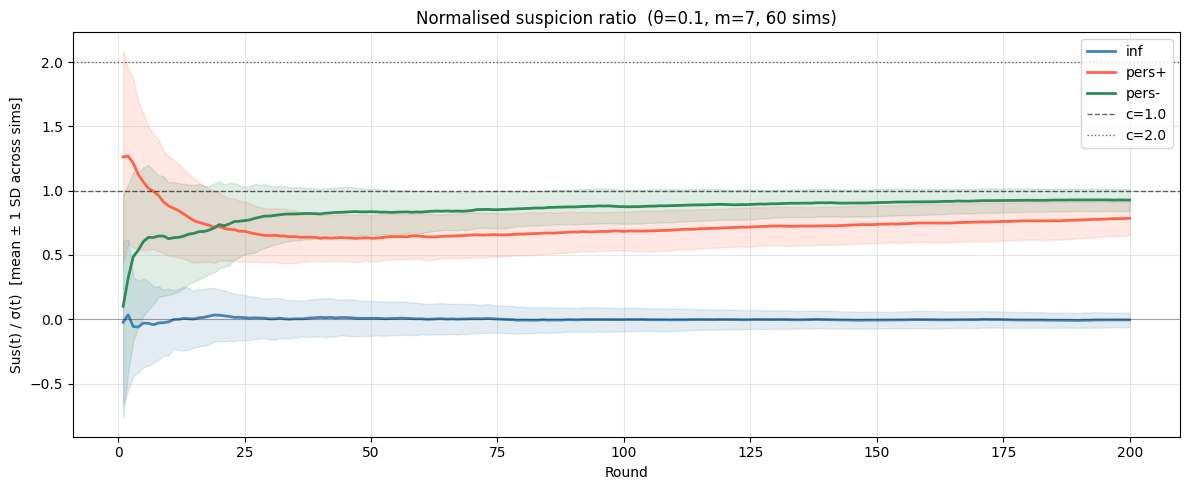

In [8]:
N_SIMS_R = 60
data_inf_r  = run_many_sims(THETA, 'inf',  n_sims=N_SIMS_R, rounds=ROUNDS, alpha=ALPHA, n=N, m=M)
data_high_r = run_many_sims(THETA, 'high', n_sims=N_SIMS_R, rounds=ROUNDS, alpha=ALPHA, n=N, m=M)
data_low_r  = run_many_sims(THETA, 'low',  n_sims=N_SIMS_R, rounds=ROUNDS, alpha=ALPHA, n=N, m=M)

fig, ax = plt.subplots(figsize=(12, 5))

for data, color, label in [
    (data_inf_r,  'steelblue', 'inf'),
    (data_high_r, 'tomato',    'pers+'),
    (data_low_r,  'seagreen',  'pers-'),
]:
    # ratio Sus(t) / sigma(t), ignoring rounds where sigma=0
    sigma = data['sigma_running']           # (n_sims, rounds)
    ratio = np.where(sigma > 1e-9,
                     data['Sus_running'] / sigma,
                     np.nan)
    x  = np.arange(1, ROUNDS + 1)
    mu = np.nanmean(ratio, axis=0)
    sd = np.nanstd(ratio, axis=0)
    ax.plot(x, mu, color=color, lw=2, label=label)
    ax.fill_between(x, mu - sd, mu + sd, color=color, alpha=0.15)

for c_val, ls in [(1.0, '--'), (2.0, ':')]:
    ax.axhline(c_val, color='k', lw=1, ls=ls, alpha=0.6, label=f'c={c_val}')

ax.axhline(0, color='k', lw=0.8, alpha=0.3)
ax.set_xlabel('Round')
ax.set_ylabel('Sus(t) / σ(t)  [mean ± 1 SD across sims]')
ax.set_title(f'Normalised suspicion ratio  (θ={THETA}, m={M}, {N_SIMS_R} sims)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Switching Rate vs c

What fraction of simulations have switched by round T, as a function of c?

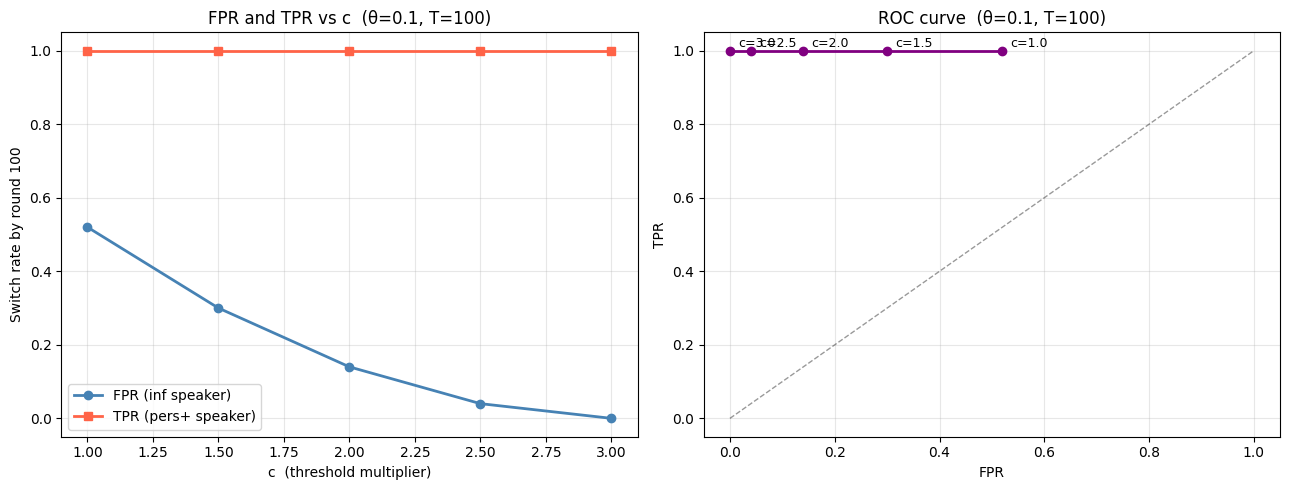

In [9]:
from rsa.experimental import estimate_fpr, estimate_tpr

C_VALS   = [1.0, 1.5, 2.0, 2.5, 3.0]
T_TARGET = 100
N_SIMS_SW = 50

world_sw     = make_world(theta=THETA, n=N, m=M)
semantics_sw = make_semantics(n=N)
thetas_sw    = make_thetas()
psis_sw      = ['inf', 'high', 'low']

fpr_at_T = []
tpr_at_T = []

for c in C_VALS:
    fpr_by_round = estimate_fpr(
        thetas_sw, psis_sw, semantics_sw, world_sw,
        c=c, alpha=ALPHA, rounds=T_TARGET, n_sims=N_SIMS_SW
    )
    tpr_by_round = estimate_tpr(
        thetas_sw, psis_sw, semantics_sw, world_sw,
        speaker_type='high', c=c, alpha=ALPHA,
        rounds=T_TARGET, n_sims=N_SIMS_SW
    )
    fpr_at_T.append(fpr_by_round[-1])
    tpr_at_T.append(tpr_by_round[-1])

fpr_at_T = np.array(fpr_at_T)
tpr_at_T = np.array(tpr_at_T)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# FPR and TPR vs c
ax = axes[0]
ax.plot(C_VALS, fpr_at_T, 'o-', color='steelblue', lw=2, label='FPR (inf speaker)')
ax.plot(C_VALS, tpr_at_T, 's-', color='tomato',    lw=2, label='TPR (pers+ speaker)')
ax.set_xlabel('c  (threshold multiplier)')
ax.set_ylabel(f'Switch rate by round {T_TARGET}')
ax.set_title(f'FPR and TPR vs c  (θ={THETA}, T={T_TARGET})')
ax.legend()
ax.grid(True, alpha=0.3)

# ROC-style: TPR vs FPR
ax = axes[1]
ax.plot(fpr_at_T, tpr_at_T, 'o-', color='purple', lw=2)
for i, c in enumerate(C_VALS):
    ax.annotate(f'c={c}', (fpr_at_T[i], tpr_at_T[i]),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ROC curve  (θ={THETA}, T={T_TARGET})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scratch